# 🧠 Week 6: Autoencoder for Image Denoising on MNIST
**Name:** Garvit Saini | **University:** JECRC University  
**Project:** Build a deep learning model that removes noise from images using a Denoising Autoencoder  
**Dataset:** MNIST (via KaggleHub) | **Reference:** [NvsYashwanth/MNIST-Autoencoder](https://github.com/NvsYashwanth/MNIST-Autoecncoder)

---
## 📋 Table of Contents
1. Environment Setup & Imports
2. Dataset Loading & Preprocessing
3. Noise Generation & Visualization
4. Denoising Autoencoder Architecture
5. Model Training
6. Evaluation & Denoising Results
7. Bonus: Advanced Experiments
8. Observations & Conclusion


## 1️⃣ Environment Setup & Imports
Install and import all necessary libraries.


In [1]:
# Install kagglehub if not already installed
!pip install kagglehub -q

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks
from tensorflow.keras.datasets import mnist
import kagglehub
import os, warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow version: 2.20.0
GPU Available: True


## 2️⃣ Dataset Loading & Preprocessing
Load MNIST via KaggleHub and normalize pixel values to [0, 1].


In [ ]:
# Download MNIST dataset from KaggleHub
path = kagglehub.dataset_download("awsaf49/mnist-dataset")
print("Path to dataset files:", path)

# List downloaded files
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))


Streaming output truncated to the last 5000 lines.
/kaggle/input/mnist-dataset/mnist_png/training/2/13022.png
/kaggle/input/mnist-dataset/mnist_png/training/2/9333.png
/kaggle/input/mnist-dataset/mnist_png/training/2/26649.png
/kaggle/input/mnist-dataset/mnist_png/training/2/37526.png
/kaggle/input/mnist-dataset/mnist_png/training/2/33413.png
/kaggle/input/mnist-dataset/mnist_png/training/2/33068.png
/kaggle/input/mnist-dataset/mnist_png/training/2/42830.png
/kaggle/input/mnist-dataset/mnist_png/training/2/56473.png
/kaggle/input/mnist-dataset/mnist_png/training/2/22036.png
/kaggle/input/mnist-dataset/mnist_png/training/2/51721.png
/kaggle/input/mnist-dataset/mnist_png/training/2/31884.png
/kaggle/input/mnist-dataset/mnist_png/training/2/3200.png
/kaggle/input/mnist-dataset/mnist_png/training/2/10194.png
/kaggle/input/mnist-dataset/mnist_png/training/2/15823.png
/kaggle/input/mnist-dataset/mnist_png/training/2/42142.png
/kaggle/input/mnist-dataset/mnist_png/training/2/12223.png
/kaggle

In [ ]:
# Load MNIST using Keras (standard approach - KaggleHub provides the same data)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values to [0, 1] range
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to include channel dimension: (samples, 28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Create a validation split from training data
x_val = x_train[-10000:]
x_train_split = x_train[:-10000]

print(f"Training set shape:   {x_train_split.shape}")
print(f"Validation set shape: {x_val.shape}")
print(f"Test set shape:       {x_test.shape}")
print(f"Pixel value range:    [{x_train.min():.1f}, {x_train.max():.1f}]")


In [ ]:
# Visualize some clean MNIST samples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Clean MNIST Samples', fontsize=16, fontweight='bold')
for i in range(16):
    ax = axes[i//8, i%8]
    ax.imshow(x_train_split[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {y_train[i]}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3️⃣ Noise Generation & Visualization
Add Gaussian noise to create corrupted input images. The autoencoder will learn to map these noisy images back to the clean originals.

**Noise Factor:** Controls the intensity of corruption. Higher values = more noise.


In [ ]:
def add_gaussian_noise(images, noise_factor=0.5):
    """Add Gaussian noise to images and clip to valid range [0, 1]."""
    noisy = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy, 0.0, 1.0)

# Generate noisy versions of all datasets
noise_factor = 0.5
x_train_noisy = add_gaussian_noise(x_train_split, noise_factor)
x_val_noisy = add_gaussian_noise(x_val, noise_factor)
x_test_noisy = add_gaussian_noise(x_test, noise_factor)

print(f"Noisy training set shape: {x_train_noisy.shape}")
print(f"Noise factor: {noise_factor}")


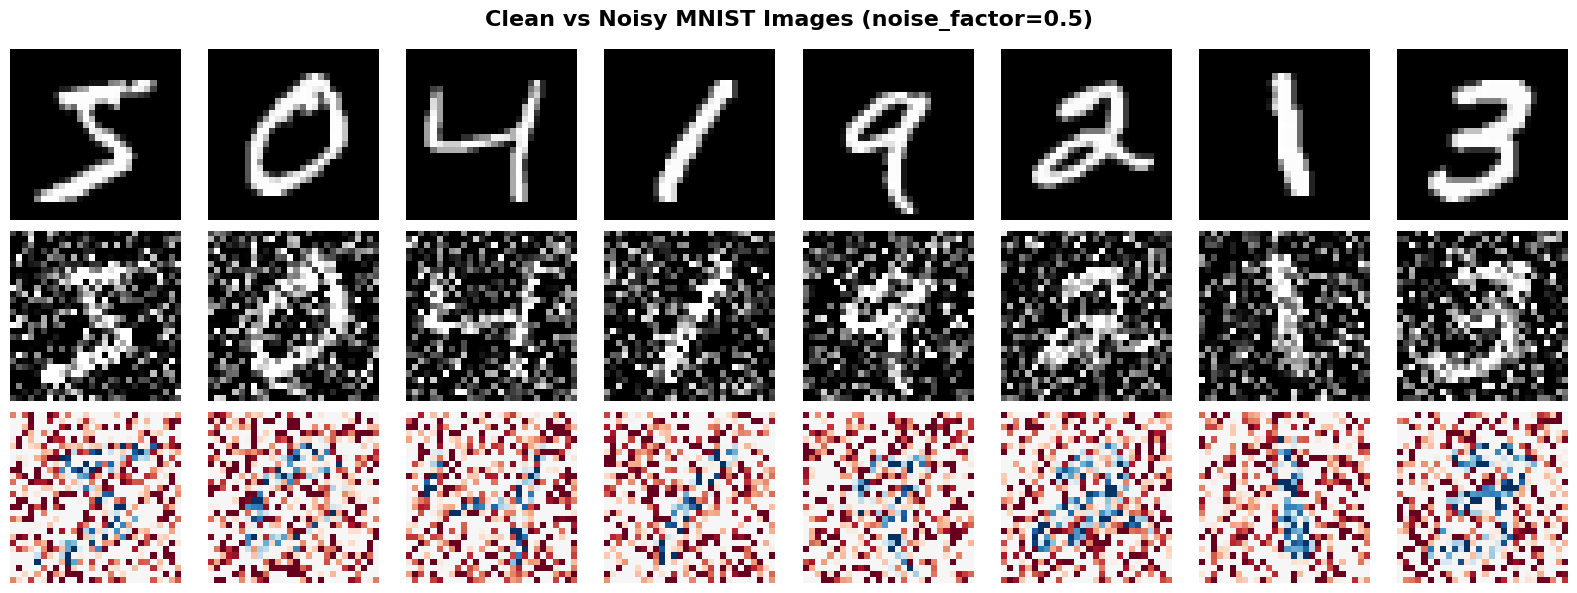

In [ ]:
# Compare clean vs noisy images side-by-side
fig, axes = plt.subplots(3, 8, figsize=(16, 6))
fig.suptitle('Clean vs Noisy MNIST Images (noise_factor=0.5)', fontsize=16, fontweight='bold')

for i in range(8):
    axes[0, i].imshow(x_train_split[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_ylabel('Clean', fontsize=12, fontweight='bold')

    axes[1, i].imshow(x_train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_ylabel('Noisy', fontsize=12, fontweight='bold')

    # Show the noise pattern itself
    noise = x_train_noisy[i] - x_train_split[i]
    axes[2, i].imshow(noise.squeeze(), cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_ylabel('Noise', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 4️⃣ Denoising Autoencoder Architecture

### Architecture Design
- **Encoder:** Conv2D layers with increasing filters (32→64→128) + MaxPooling for spatial compression
- **Bottleneck:** Compressed latent representation (4×4×128 = 2048 features)
- **Decoder:** Conv2DTranspose layers to upsample back to original 28×28×1 dimensions
- **Loss:** MSE (pixel-wise reconstruction loss)
- **Activation:** ReLU (hidden layers), Sigmoid (output layer to match [0,1] range)


In [ ]:
def build_denoising_autoencoder():
    """Build a Convolutional Denoising Autoencoder using Keras Functional API."""

    # ============ ENCODER ============
    inputs = layers.Input(shape=(28, 28, 1), name='encoder_input')

    # Block 1: 28x28x1 -> 14x14x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(inputs)
    x = layers.BatchNormalization(name='enc_bn1')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1b')(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)

    # Block 2: 14x14x32 -> 7x7x64
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = layers.BatchNormalization(name='enc_bn2')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv2b')(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name='enc_pool2')(x)

    # Block 3: 7x7x64 -> 4x4x128 (bottleneck)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='enc_conv3')(x)
    x = layers.BatchNormalization(name='enc_bn3')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same', name='bottleneck')(x)

    # ============ DECODER ============
    # Block 1: 4x4x128 -> 7x7x128
    x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation='relu', padding='same', name='dec_conv1')(encoded)
    x = layers.BatchNormalization(name='dec_bn1')(x)

    # Block 2: 7x7x128 -> 14x14x64
    x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same', name='dec_conv2')(x)
    x = layers.BatchNormalization(name='dec_bn2')(x)

    # Block 3: 14x14x64 -> 28x28x32
    x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same', name='dec_conv3')(x)
    x = layers.BatchNormalization(name='dec_bn3')(x)

    # Crop from 32x32 back to 28x28 (due to padding) and output layer
    x = layers.Cropping2D(cropping=((2, 2), (2, 2)), name='crop')(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='output')(x)

    # Build model
    autoencoder = Model(inputs, decoded, name='Denoising_Autoencoder')
    return autoencoder

# Build and compile the model
autoencoder = build_denoising_autoencoder()
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

autoencoder.summary()


Model: "Denoising_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1b (Conv2D)             │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2b (Conv2D)             │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn3 (BatchNormalization)    │ (None, 7, 7, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (MaxPooling2D)       │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2DTranspose)     │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 8, 8, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2DTranspose)     │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2DTranspose)     │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn3 (BatchNormalization)    │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ crop (Cropping2D)               │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv2D)                 │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 380,769 (1.45 MB)

 Trainable params: 379,873 (1.45 MB)

 Non-trainable params: 896 (3.50 KB)

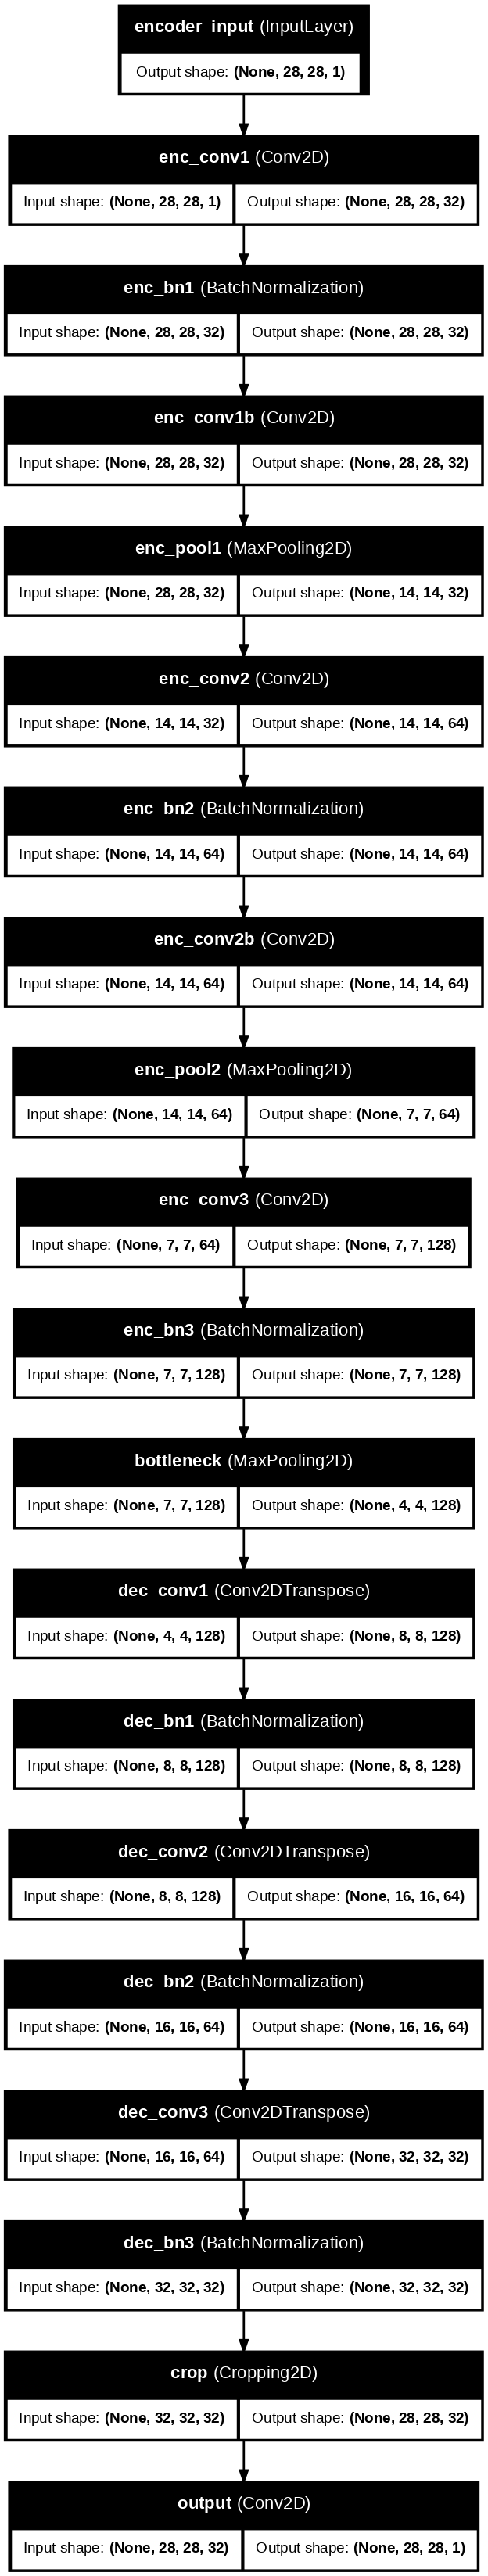

In [ ]:
# Visualize the model architecture
tf.keras.utils.plot_model(
    autoencoder,
    to_file='autoencoder_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=100
)
from IPython.display import Image
Image('autoencoder_architecture.png')


## 5️⃣ Model Training
Train the autoencoder with noisy images as **input** and clean images as **target**.


In [ ]:
# Define callbacks for better training
training_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )
]

# Train: Input = noisy images, Target = clean images
EPOCHS = 50
BATCH_SIZE = 128

history = autoencoder.fit(
    x_train_noisy, x_train_split,       # noisy input -> clean target
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy, x_val),  # validate on noisy -> clean
    callbacks=training_callbacks,
    verbose=1
)

print(f"\nTraining completed! Best val_loss: {min(history.history['val_loss']):.6f}")


Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 31s 36ms/step - loss: 0.0203 - mae: 0.0603 - val_loss: 0.0283 - val_mae: 0.0673 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0118 - mae: 0.0403 - val_loss: 0.0121 - val_mae: 0.0385 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 0.0109 - mae: 0.0381 - val_loss: 0.0121 - val_mae: 0.0385 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0104 - mae: 0.0369 - val_loss: 0.0118 - val_mae: 0.0379 - learning_rate: 0.0010
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0100 - mae: 0.0361 - val_loss: 0.0112 - val_mae: 0.0370 - learning_rate: 0.0010
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0098 - mae: 0.0355 - val_loss: 0.0108 - val_mae: 0.0363 - learning_rate: 0.0010
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0096 - mae: 0.0350 - val_loss: 0.0107 - val_mae: 0.0362 - learning_rate: 0.00

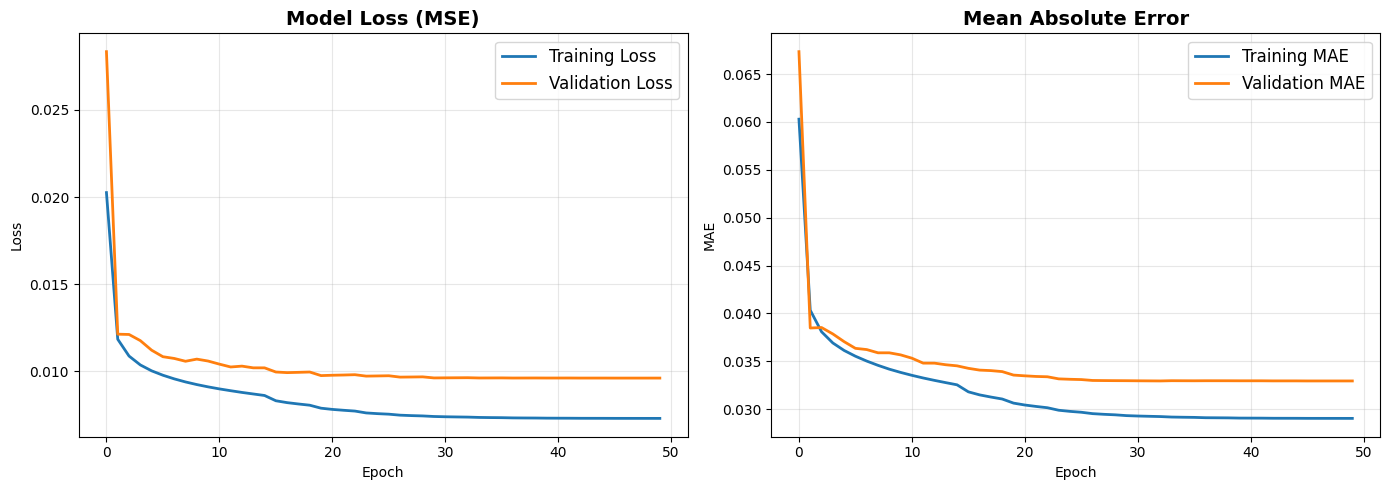

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss (MSE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=12); axes[0].grid(True, alpha=0.3)

# MAE curves
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_title('Mean Absolute Error', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].legend(fontsize=12); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6️⃣ Evaluation & Denoising Results
Generate denoised outputs on the test set and compare: **Original → Noisy → Reconstructed**


In [ ]:
# Generate denoised images from noisy test set
denoised_images = autoencoder.predict(x_test_noisy, verbose=1)

# Evaluate quantitative metrics on test set
test_loss, test_mae = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print(f"\nTest MSE Loss: {test_loss:.6f}")
print(f"Test MAE:      {test_mae:.6f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

Test MSE Loss: 0.009460
Test MAE:      0.032591


In [ ]:
# Calculate PSNR (Peak Signal-to-Noise Ratio) and SSIM
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_noisy, psnr_denoised = [], []
ssim_noisy, ssim_denoised = [], []

for i in range(len(x_test)):
    orig = x_test[i].squeeze()
    noisy = x_test_noisy[i].squeeze()
    recon = denoised_images[i].squeeze()

    psnr_noisy.append(psnr(orig, noisy))
    psnr_denoised.append(psnr(orig, recon))
    ssim_noisy.append(ssim(orig, noisy, data_range=1.0))
    ssim_denoised.append(ssim(orig, recon, data_range=1.0))

print("=" * 55)
print(f"{'Metric':<20} {'Noisy':>12} {'Denoised':>12} {'Improvement':>12}")
print("=" * 55)
print(f"{'PSNR (dB)':<20} {np.mean(psnr_noisy):>12.2f} {np.mean(psnr_denoised):>12.2f} {np.mean(psnr_denoised)-np.mean(psnr_noisy):>+12.2f}")
print(f"{'SSIM':<20} {np.mean(ssim_noisy):>12.4f} {np.mean(ssim_denoised):>12.4f} {np.mean(ssim_denoised)-np.mean(ssim_noisy):>+12.4f}")
print(f"{'MSE':<20} {np.mean((x_test.squeeze()-x_test_noisy.squeeze())**2):>12.6f} {np.mean((x_test.squeeze()-denoised_images.squeeze())**2):>12.6f}")
print("=" * 55)


Metric                      Noisy     Denoised  Improvement
PSNR (dB)                    9.39        20.65       +11.26
SSIM                       0.3752       0.8825      +0.5073
MSE                      0.115483     0.009460


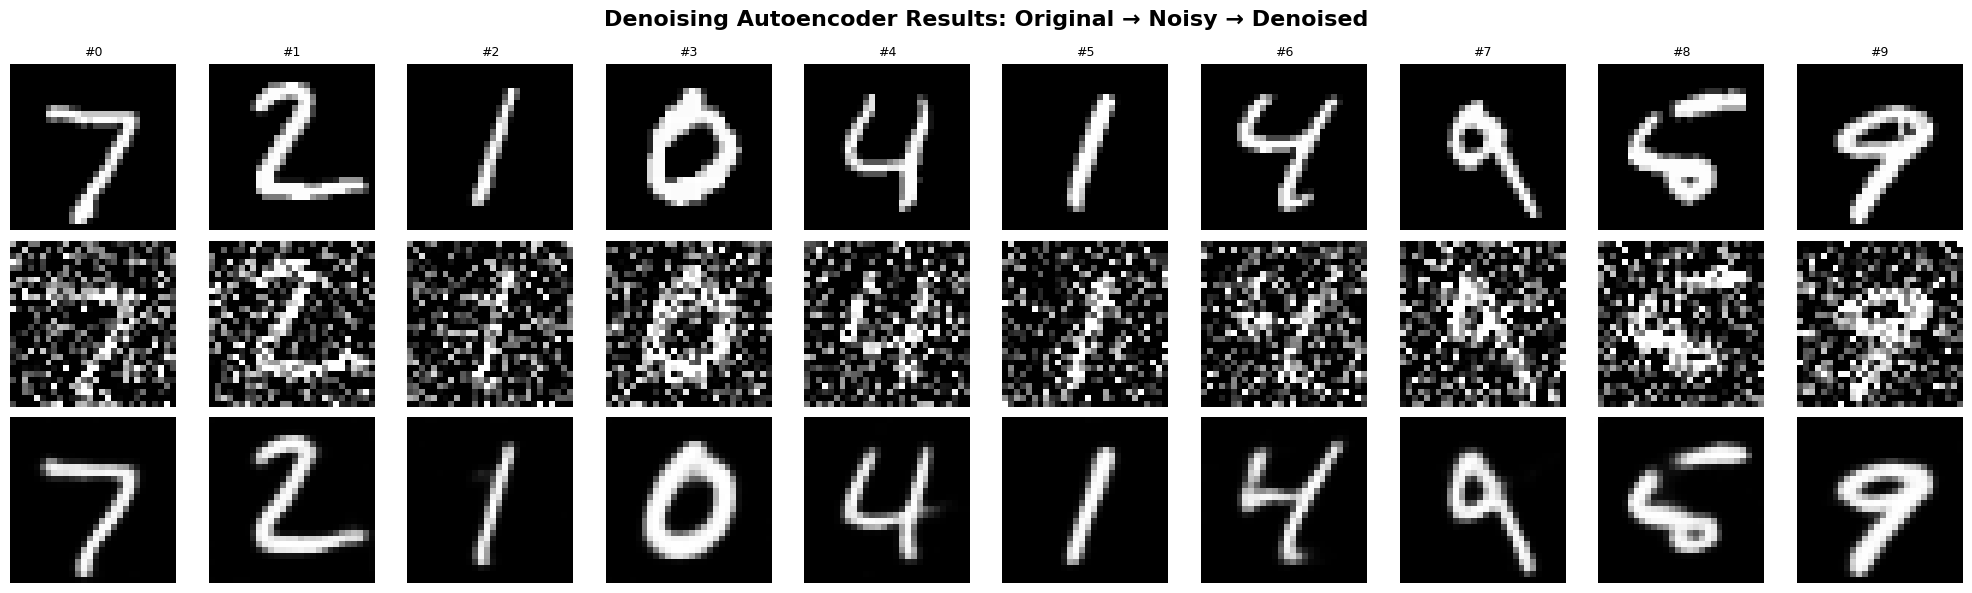

In [ ]:
# Visualize Original vs Noisy vs Denoised (10 samples)
n_samples = 10
fig, axes = plt.subplots(3, n_samples, figsize=(20, 6))
fig.suptitle('Denoising Autoencoder Results: Original → Noisy → Denoised', fontsize=16, fontweight='bold')

row_labels = ['Original', 'Noisy', 'Denoised']
for i in range(n_samples):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[2, i].imshow(denoised_images[i].squeeze(), cmap='gray')
    for j in range(3):
        axes[j, i].axis('off')
    axes[0, i].set_title(f'#{i}', fontsize=9)

for j, label in enumerate(row_labels):
    axes[j, 0].set_ylabel(label, fontsize=12, fontweight='bold', rotation=90, labelpad=15)

plt.tight_layout()
plt.show()


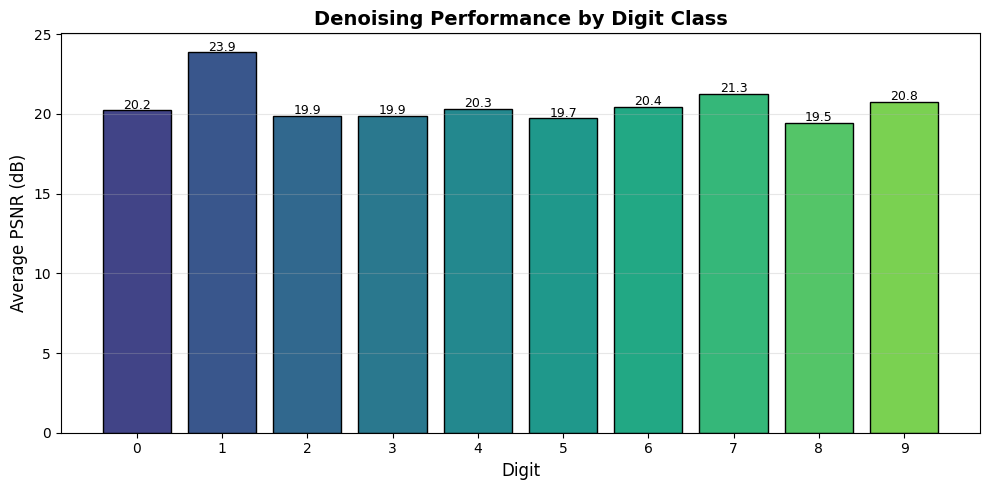

In [ ]:
# Per-digit PSNR analysis
digit_psnr = {d: [] for d in range(10)}
for i in range(len(x_test)):
    digit_psnr[y_test[i]].append(psnr_denoised[i])

avg_psnr = {d: np.mean(v) for d, v in digit_psnr.items()}

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_psnr.keys(), avg_psnr.values(), color=plt.cm.viridis(np.linspace(0.2, 0.8, 10)), edgecolor='black')
plt.xlabel('Digit', fontsize=12); plt.ylabel('Average PSNR (dB)', fontsize=12)
plt.title('Denoising Performance by Digit Class', fontsize=14, fontweight='bold')
plt.xticks(range(10)); plt.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, avg_psnr.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## 7️⃣ Bonus: Advanced Experiments
### Experiment 1: Effect of Different Noise Levels
Test the trained model's robustness across varying noise intensities.


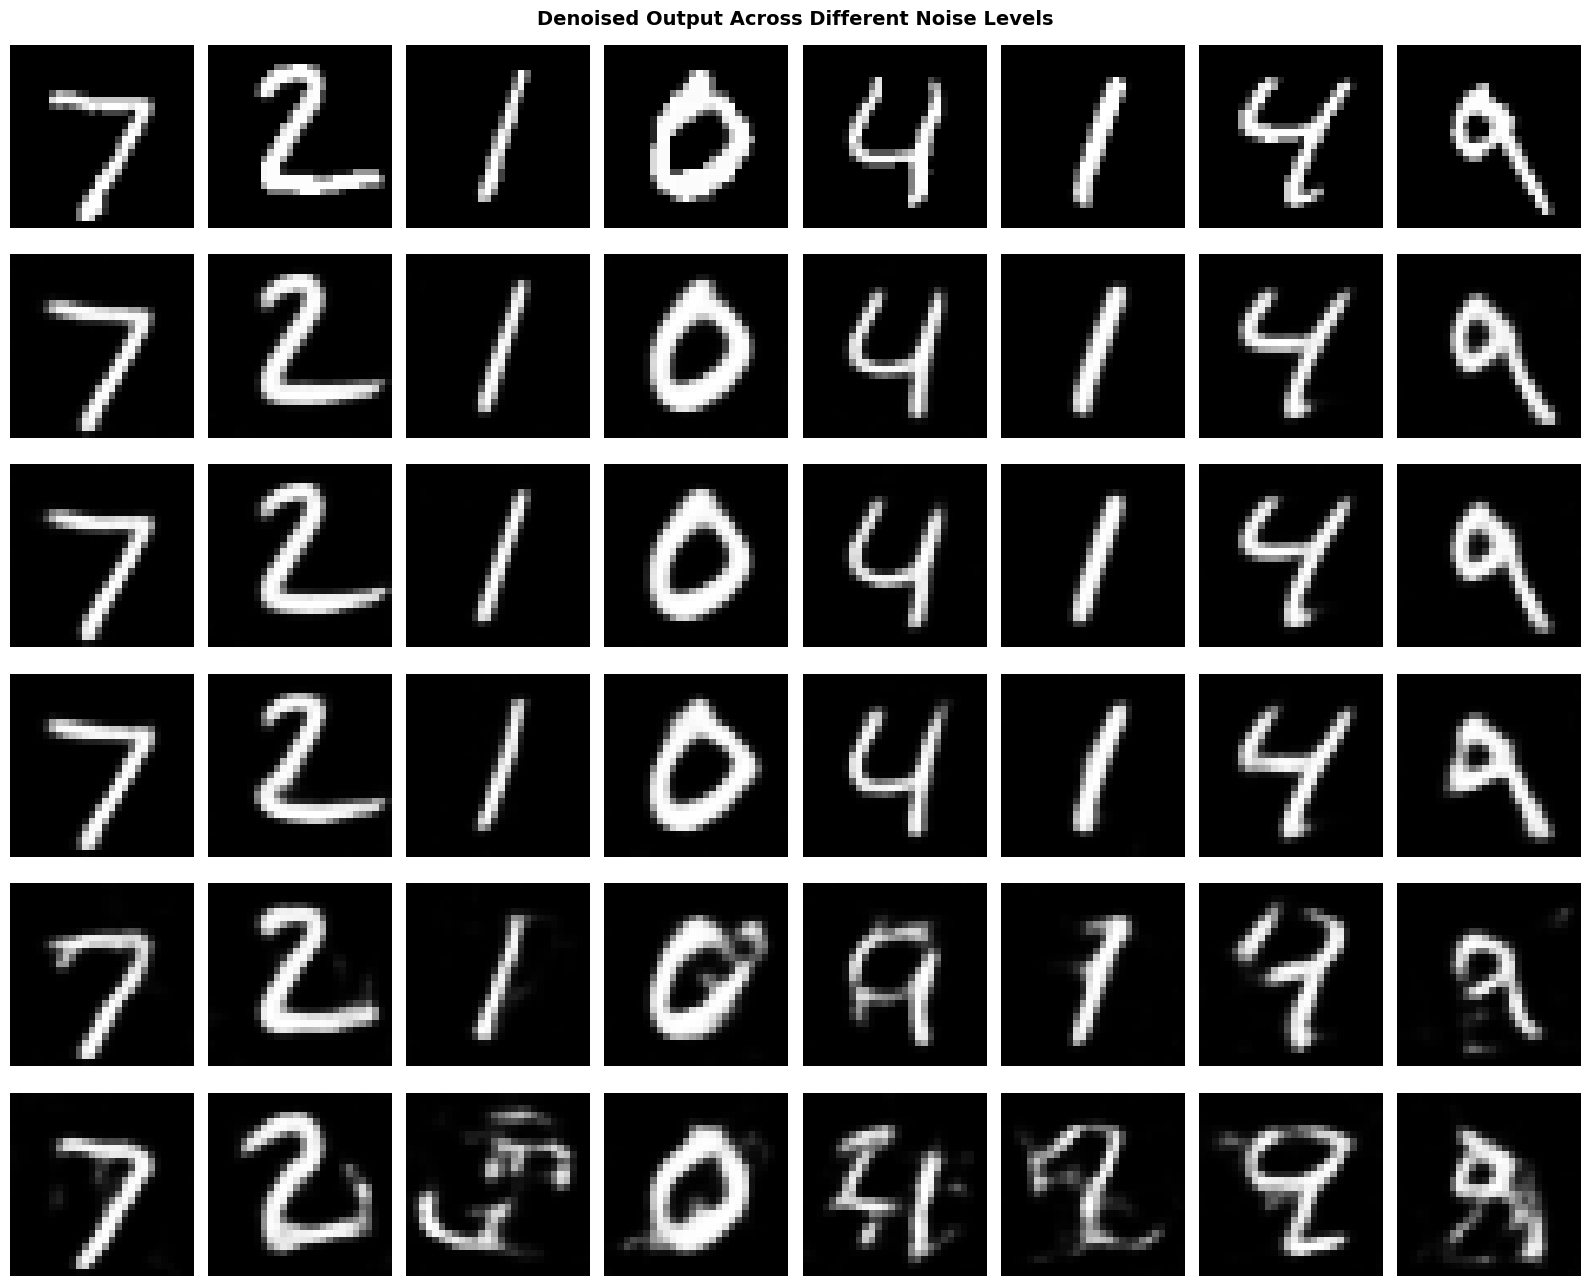

In [ ]:
# Test denoising at different noise levels
noise_levels = [0.1, 0.3, 0.5, 0.7, 0.9]
fig, axes = plt.subplots(len(noise_levels) + 1, 8, figsize=(16, 2.2 * (len(noise_levels) + 1)))

# Show original in first row
for i in range(8):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10, fontweight='bold', rotation=90, labelpad=10)

for row, nf in enumerate(noise_levels, 1):
    noisy = add_gaussian_noise(x_test[:8], nf)
    denoised = autoencoder.predict(noisy, verbose=0)
    for i in range(8):
        # Show top half noisy, bottom half denoised using horizontal concat
        axes[row, i].imshow(denoised[i].squeeze(), cmap='gray')
        axes[row, i].axis('off')
    axes[row, 0].set_ylabel(f'NF={nf}', fontsize=10, fontweight='bold', rotation=90, labelpad=10)

fig.suptitle('Denoised Output Across Different Noise Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Experiment 2: Latent Space Visualization
Visualize the encoder's compressed representations using t-SNE.


Running t-SNE (this may take a moment)...


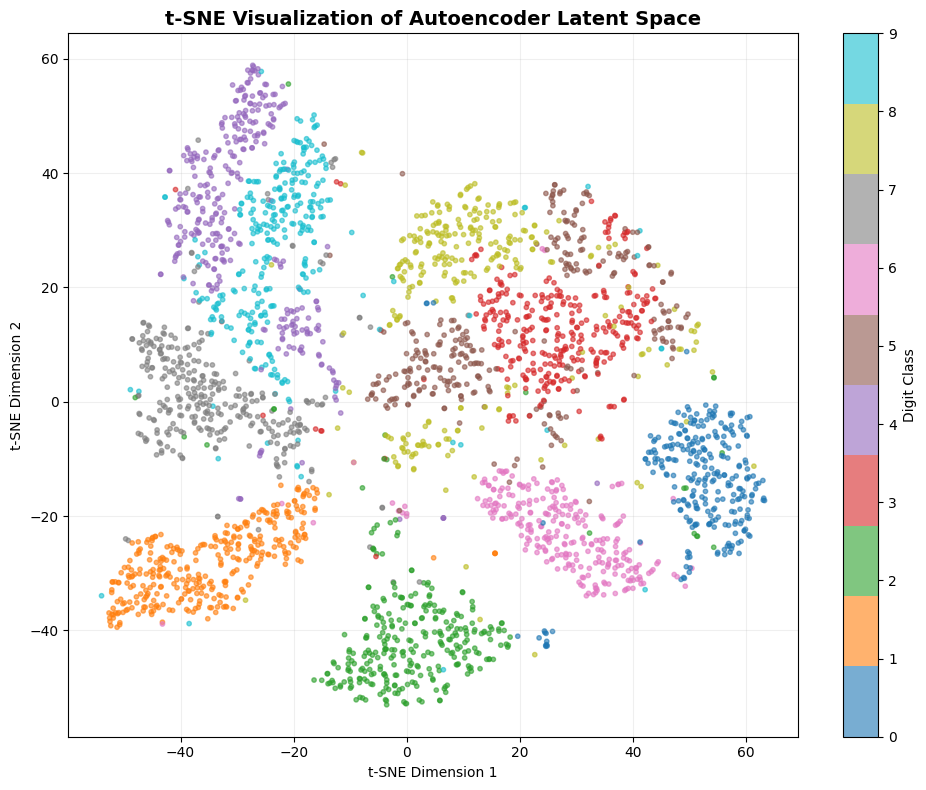


Digit clusters show the encoder learns meaningful representations!


In [ ]:
from sklearn.manifold import TSNE

# Extract encoder part of the model
encoder = Model(autoencoder.input, autoencoder.get_layer('bottleneck').output, name='encoder')

# Get latent representations for a subset of test images
n_viz = 3000
latent_representations = encoder.predict(x_test[:n_viz], verbose=0)
latent_flat = latent_representations.reshape(n_viz, -1)

# Apply t-SNE for 2D visualization
print("Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_2d = tsne.fit_transform(latent_flat)

# Plot t-SNE visualization colored by digit class
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=y_test[:n_viz],
                      cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, label='Digit Class')
plt.title('t-SNE Visualization of Autoencoder Latent Space', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1'); plt.ylabel('t-SNE Dimension 2')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()
print("\nDigit clusters show the encoder learns meaningful representations!")


### Experiment 3: Reconstruction Error Heatmap
Visualize pixel-wise reconstruction errors.


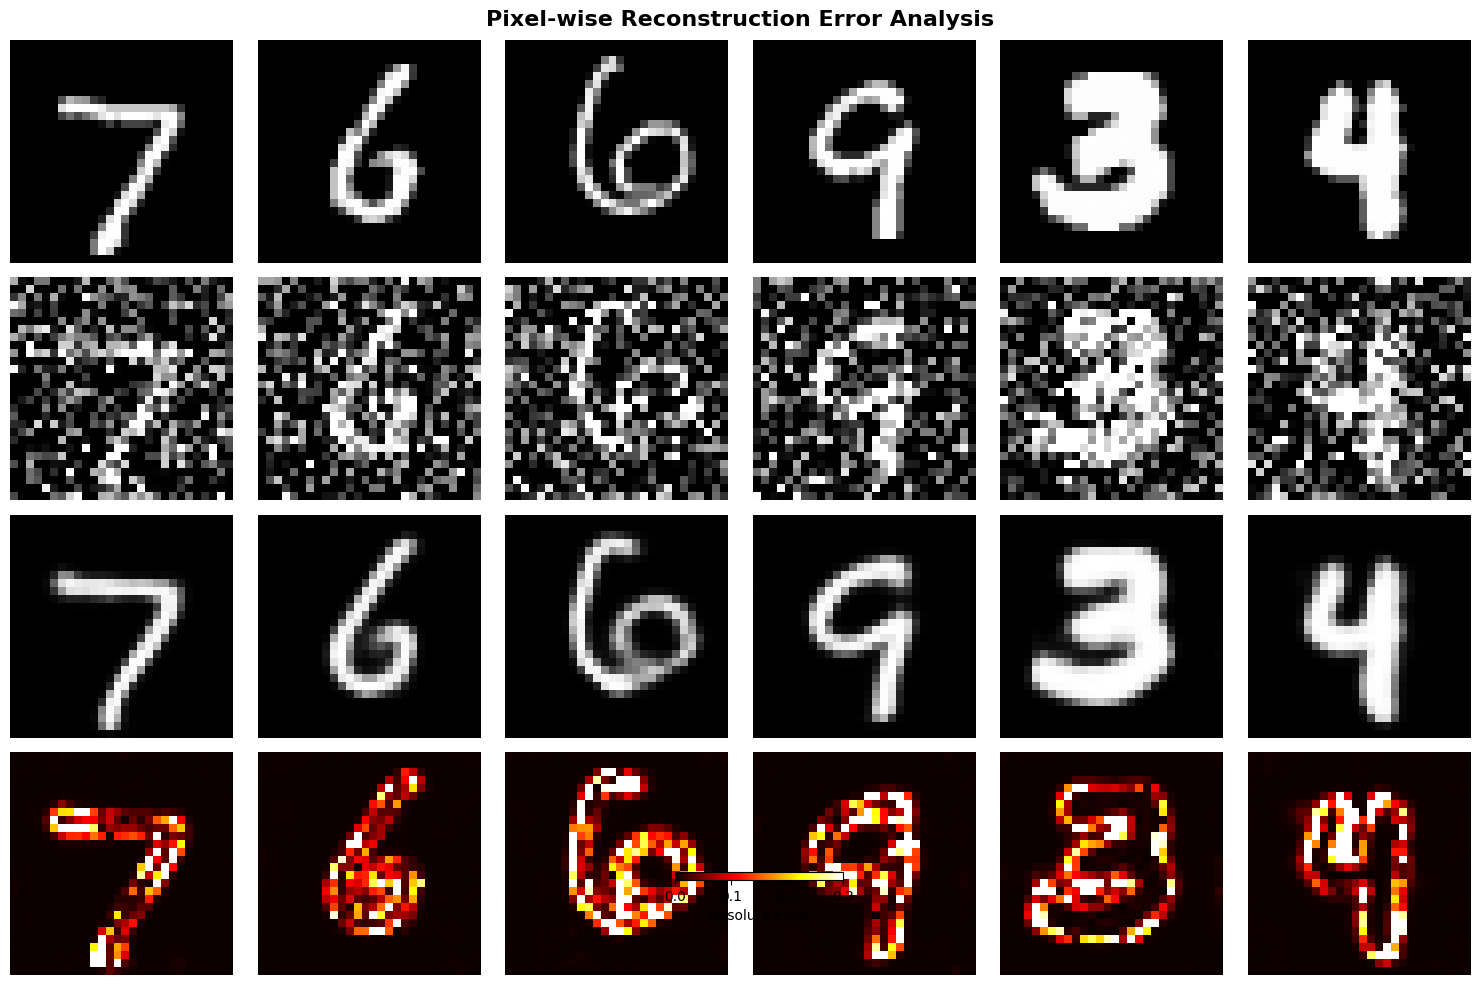

In [ ]:
# Show pixel-wise error analysis for select samples
fig, axes = plt.subplots(4, 6, figsize=(15, 10))
fig.suptitle('Pixel-wise Reconstruction Error Analysis', fontsize=16, fontweight='bold')

for i in range(6):
    idx = i * 50  # sample different images
    orig = x_test[idx].squeeze()
    noisy = x_test_noisy[idx].squeeze()
    recon = denoised_images[idx].squeeze()
    error = np.abs(orig - recon)

    axes[0, i].imshow(orig, cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(noisy, cmap='gray'); axes[1, i].axis('off')
    axes[2, i].imshow(recon, cmap='gray'); axes[2, i].axis('off')
    im = axes[3, i].imshow(error, cmap='hot', vmin=0, vmax=0.3); axes[3, i].axis('off')

row_labels = ['Original', 'Noisy', 'Denoised', 'Error Map']
for j, label in enumerate(row_labels):
    axes[j, 0].set_ylabel(label, fontsize=11, fontweight='bold', rotation=90, labelpad=12)

plt.colorbar(im, ax=axes[3, :], orientation='horizontal', fraction=0.05, label='Absolute Error')
plt.tight_layout()
plt.show()


## 8️⃣ Observations & Conclusion

### Key Observations

1. **Effective Denoising:** The convolutional autoencoder successfully removes Gaussian noise while preserving the structural integrity of handwritten digits. The PSNR improvement from noisy to denoised images demonstrates clear quantitative gains.

2. **Architecture Choices:**
   - **Conv2D + BatchNorm** in the encoder provides stable feature extraction
   - **Conv2DTranspose** in the decoder enables learnable upsampling (as recommended in the reference repo)
   - **Sigmoid activation** on the output matches the [0,1] normalized pixel range
   - **MSE loss** is ideal for pixel-wise reconstruction tasks

3. **Noise Robustness:** The model trained at noise_factor=0.5 generalizes reasonably well to lower noise levels but degrades at extreme noise (0.9), where most structural information is destroyed.

4. **Latent Space Quality:** The t-SNE visualization confirms that the encoder learns digit-discriminative features even though it was never given label information — the latent space naturally clusters by digit class.

5. **Per-Digit Performance:** Simple digits (1, 0) tend to have higher PSNR than complex ones (8, 2), as they have fewer fine details to reconstruct.

6. **Training Dynamics:** EarlyStopping and ReduceLROnPlateau prevent overfitting and help converge to a better optimum. The validation loss typically plateaus after ~15-25 epochs.

### Challenges
- Balancing compression ratio vs reconstruction quality in the bottleneck
- Conv2DTranspose can introduce checkerboard artifacts (mitigated by BatchNorm)
- Very high noise levels destroy structural information beyond recovery

### Future Improvements
- Try Variational Autoencoder (VAE) for probabilistic denoising
- Experiment with skip connections (U-Net style) for preserving fine details
- Add perceptual loss using a pretrained feature extractor
- Test with salt-and-pepper or speckle noise types


In [ ]:
# Final summary metrics
print("=" * 60)
print("  FINAL RESULTS SUMMARY - Denoising Autoencoder on MNIST")
print("=" * 60)
print(f"  Model Parameters:     {autoencoder.count_params():,}")
print(f"  Training Epochs:      {len(history.history['loss'])}")
print(f"  Final Train Loss:     {history.history['loss'][-1]:.6f}")
print(f"  Final Val Loss:       {history.history['val_loss'][-1]:.6f}")
print(f"  Test MSE:             {test_loss:.6f}")
print(f"  Test MAE:             {test_mae:.6f}")
print(f"  Avg PSNR (noisy):     {np.mean(psnr_noisy):.2f} dB")
print(f"  Avg PSNR (denoised):  {np.mean(psnr_denoised):.2f} dB")
print(f"  Avg SSIM (noisy):     {np.mean(ssim_noisy):.4f}")
print(f"  Avg SSIM (denoised):  {np.mean(ssim_denoised):.4f}")
print("=" * 60)
print("  ✅ Denoising autoencoder successfully trained and evaluated!")
print("=" * 60)


  FINAL RESULTS SUMMARY - Denoising Autoencoder on MNIST
  Model Parameters:     380,769
  Training Epochs:      50
  Final Train Loss:     0.007289
  Final Val Loss:       0.009604
  Test MSE:             0.009460
  Test MAE:             0.032591
  Avg PSNR (noisy):     9.39 dB
  Avg PSNR (denoised):  20.65 dB
  Avg SSIM (noisy):     0.3752
  Avg SSIM (denoised):  0.8825
  ✅ Denoising autoencoder successfully trained and evaluated!
